# Risk-aware MCTS
#### `binpacking` experiments

In [29]:
import os
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker
import seaborn as sns
sns.set_style("dark")

matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams.update({'font.size': 16})

sns.set_palette("colorblind")

In [40]:
def calculate_erm(dist, beta):
    dist = np.asarray(dist)
    return (1.0 / beta) * np.log((1 / len(dist)) * np.sum(np.exp(beta * dist)))

In [41]:
def erm_ci(samples: np.ndarray, beta: float, num_resamples: int = 25_000):
    # Confidence interval estimation via bootstrap resampling.
    samples = np.asarray(samples)
    resampled = np.random.choice(samples, size=(len(samples), num_resamples), replace=True).T
    erms = (1.0 / beta) * np.log((1 / resampled.shape[1]) * np.sum(np.exp(beta * resampled), axis=1))
    return [np.percentile(erms, 5), np.percentile(erms, 95)]

### Load experiment data

Reads every completed cell for this environment from the sweep's `manifest.json` / `exp_data.json` files (output of `run_experiments.py`).

In [58]:
SWEEP_DIR = 'data/sweep_demo_2026-09-24-14-53-19_seed0' # 'data/sweep_demo_2026-09-23-18-28-13_seed0'
ENV_NAME = 'binpacking'

with open(os.path.join(SWEEP_DIR, "manifest.json")) as f:
    manifest = json.load(f)

# algo -> beta -> n_iter -> f_vals   (n_iter is None for erm-bi, which doesn't use it)
data = {}
for cell_name, meta in manifest["cells"].items():
    if meta["env"] != ENV_NAME or meta["status"] != "done":
        continue
    exp_path = os.path.join(SWEEP_DIR, cell_name, "exp_data.json")
    with open(exp_path) as f:
        raw = json.load(f)
    exp = json.loads(raw) if isinstance(raw, str) else raw

    algo = meta["algo"]
    beta = meta["erm_beta"]
    n_iter = meta["n_iter"]  # None for erm-bi
    data.setdefault(algo, {}).setdefault(beta, {})[n_iter] = exp["f_vals"]

algos = sorted(data.keys())
betas = sorted({b for algo_d in data.values() for b in algo_d.keys()})
n_iters = sorted({n for algo_d in data.values() for beta_d in algo_d.values() for n in beta_d.keys() if n is not None})
n_iter_to_plot = n_iters[-1] if n_iters else None  # n_iter slice used by the plots below

print("algos:", algos)
print("betas:", betas)
print("n_iters:", n_iters)
print("n_iter_to_plot:", n_iter_to_plot)

algos: ['erm-mcts']
betas: [1, 25]
n_iters: [2000]
n_iter_to_plot: 2000


### ERM vs. planning budget (`n_iter`), for a fixed `beta`

Compares the sampling-based planners (`erm-mcts`, `acc-mcts`) as the per-timestep iteration budget grows. `erm-bi`, the exact oracle, doesn't depend on `n_iter` and is drawn as a flat reference line when available.

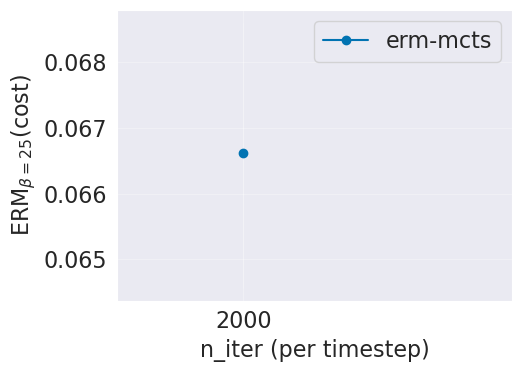

In [59]:
erm_beta_to_plot = betas[-1]

fig, ax = plt.subplots(figsize=(5.5, 4.0))

for algo, algo_d in data.items():
    if erm_beta_to_plot not in algo_d:
        continue
    beta_d = algo_d[erm_beta_to_plot]

    if algo == "erm-bi":
        # Oracle: no n_iter dependence, draw as a horizontal reference line.
        f_vals = beta_d[None]
        erm_val = calculate_erm(f_vals, beta=erm_beta_to_plot)
        ax.axhline(erm_val, linestyle="--", color="black", label="erm-bi (oracle)")
        continue

    xs = sorted(n for n in beta_d.keys() if n is not None)
    ys = [calculate_erm(beta_d[n], beta=erm_beta_to_plot) for n in xs]
    cis = [erm_ci(beta_d[n], beta=erm_beta_to_plot) for n in xs]
    lower = [y - ci[0] for y, ci in zip(ys, cis)]
    upper = [ci[1] - y for y, ci in zip(ys, cis)]

    ax.plot(xs, ys, marker="o", label=algo)
    ax.fill_between(xs, np.array(ys) - lower, np.array(ys) + upper, alpha=0.2)

ax.set_xlabel("n_iter (per timestep)")
ax.set_ylabel(fr"ERM$_{{\beta={erm_beta_to_plot}}}$(cost)")
ax.set_xscale("log")
ax.set_xticks(n_iters)
ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.get_xaxis().set_minor_formatter(matplotlib.ticker.NullFormatter())
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

### Distribution of costs, per algorithm

Histogram of the (discounted) cumulative cost `f_vals` across episodes, one panel per algorithm, overlaying all `beta` values at the fixed `n_iter` chosen above.

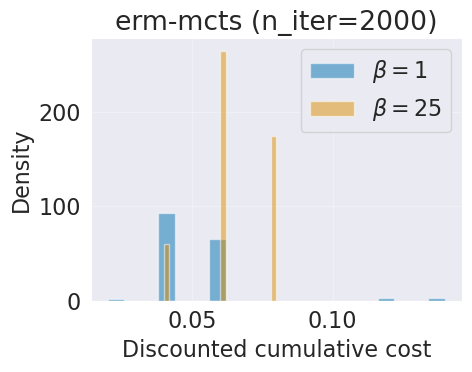

In [60]:
fig, axes = plt.subplots(1, len(algos), figsize=(5.0 * len(algos), 4.0), sharey=True)
if len(algos) == 1:
    axes = [axes]

for ax, algo in zip(axes, algos):
    algo_d = data[algo]
    for beta in betas:
        if beta not in algo_d:
            continue
        key = None if algo == "erm-bi" else n_iter_to_plot
        if key not in algo_d[beta]:
            continue
        ax.hist(algo_d[beta][key], density=True, bins=20, alpha=0.5, label=fr"$\beta={beta}$")
    ax.set_title(f"{algo} (n_iter={n_iter_to_plot})")
    ax.set_xlabel("Discounted cumulative cost")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Density")
axes[0].legend()
fig.tight_layout()
plt.show()

### Boxplot comparison across algorithms and betas (fixed `n_iter`)

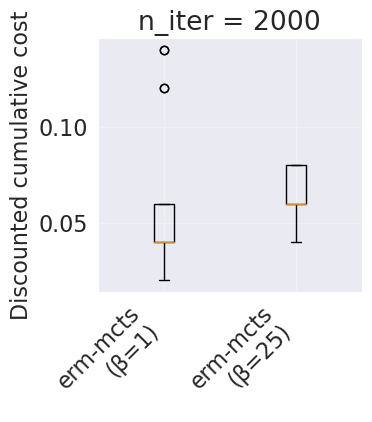

In [61]:
fig, ax = plt.subplots(figsize=(2.0 * len(algos) * len(betas), 4.5))

data_to_plot, labels = [], []
for algo in algos:
    algo_d = data[algo]
    for beta in betas:
        if beta not in algo_d:
            continue
        key = None if algo == "erm-bi" else n_iter_to_plot
        if key not in algo_d[beta]:
            continue
        data_to_plot.append(algo_d[beta][key])
        labels.append(f"{algo}\n(β={beta})")

ax.boxplot(data_to_plot, labels=labels)
ax.set_title(f"n_iter = {n_iter_to_plot}")
ax.set_ylabel("Discounted cumulative cost")
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
plt.show()

### ERM-MCTS: most-visited vs. min-ERM root action

Reads `decisions.jsonl` from every `erm-mcts` cell at `n_iter_to_plot`. At each real step, `run_experiments.py` logged which root action each criterion would pick. Only the action chosen by `ERMMCTS.best_action_criterion` was actually executed, so everything here describes the trajectories that criterion produced.

- **Top left:** share of steps where the two criteria pick different actions, per `beta`. The hatched part is steps where the most-visited action is only a tie on visit counts (`argmax` then just takes the first action), so the disagreement there isn't a real preference.
- **Top right:** the same disagreement rate at each timestep `t` of the episode.
- **Bottom left:** when they disagree, how much worse the most-visited action's estimated ERM is than the min-ERM action's (`ERM[most_visited] - ERM[min_erm]`, in cost units, always >= 0).
- **Bottom right:** per episode, the number of disagreement steps against the episode's cumulative cost.

In [ ]:
# beta -> list of episodes ({"seed", "f_val", "steps": [...]}), erm-mcts at n_iter_to_plot only
decisions = {}
for cell_name, meta in manifest["cells"].items():
    if (meta["env"] != ENV_NAME or meta["status"] != "done" or meta["algo"] != "erm-mcts"
            or meta["n_iter"] != n_iter_to_plot):
        continue
    path = os.path.join(SWEEP_DIR, cell_name, "decisions.jsonl")
    if os.path.exists(path):  # sweeps run before the decision logging existed have no decisions.jsonl
        with open(path) as f:
            decisions[meta["erm_beta"]] = [json.loads(line) for line in f]

if not decisions:
    print(f"No decisions.jsonl for erm-mcts (n_iter={n_iter_to_plot}) in {SWEEP_DIR}: nothing to plot.")
else:
    dec_betas = sorted(decisions)
    colors = {b: sns.color_palette()[betas.index(b) % 10] for b in dec_betas}  # same color per beta in every panel

    def is_visit_tie(step):
        return step["visits"].count(max(step["visits"])) > 1

    fig, axes = plt.subplots(2, 2, figsize=(13, 9.5))
    (ax_rate, ax_t), (ax_gap, ax_ep) = axes

    # Top left: disagreement rate per beta, split into real disagreements and visit-count ties.
    for i, beta in enumerate(dec_betas):
        steps = [s for ep in decisions[beta] for s in ep["steps"]]
        n_tie = sum(not s["agree"] and is_visit_tie(s) for s in steps)
        n_real = sum(not s["agree"] and not is_visit_tie(s) for s in steps)
        ax_rate.bar(i, n_real / len(steps), width=0.6, color=colors[beta], edgecolor="white", linewidth=2)
        ax_rate.bar(i, n_tie / len(steps), width=0.6, bottom=n_real / len(steps), color=colors[beta],
                    alpha=0.45, hatch="//", edgecolor="white", linewidth=2)
        ax_rate.annotate(f"{(n_real + n_tie) / len(steps):.1%}", (i, (n_real + n_tie) / len(steps)),
                         xytext=(0, 4), textcoords="offset points", ha="center", fontsize=12)
    max_rate = max(p.get_y() + p.get_height() for p in ax_rate.patches)
    ax_rate.set_ylim(0, max(max_rate * 1.2, 0.05))
    ax_rate.bar(0, 0, color="gray", label="different preference")
    ax_rate.bar(0, 0, color="gray", alpha=0.45, hatch="//", label="visit-count tie")
    ax_rate.set_xticks(range(len(dec_betas)))
    ax_rate.set_xticklabels([fr"$\beta={b}$" for b in dec_betas])
    ax_rate.set_ylabel("Steps where criteria disagree")
    ax_rate.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))
    ax_rate.legend(fontsize=12, loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False)

    # Top right: disagreement rate at each timestep t.
    for beta in dec_betas:
        by_t = {}
        for ep in decisions[beta]:
            for s in ep["steps"]:
                by_t.setdefault(s["t"], []).append(not s["agree"])
        ts = sorted(by_t)
        ax_t.plot(ts, [np.mean(by_t[t]) for t in ts], marker="o", markersize=5, linewidth=2,
                  color=colors[beta], label=fr"$\beta={beta}$")
    ax_t.set_xlabel("Timestep t")
    ax_t.set_ylabel("Steps where criteria disagree")
    ax_t.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))
    ax_t.legend(fontsize=12)

    # Bottom left: ERM gap between the two candidate actions, at disagreement steps only (shared bins across betas).
    gaps = {}
    for beta in dec_betas:
        gaps[beta] = []
        for ep in decisions[beta]:
            for s in ep["steps"]:
                if not s["agree"]:
                    erm = dict(zip(s["actions"], s["erms"]))
                    gaps[beta].append(erm[s["most_visited"]] - erm[s["min_erm"]])
    all_gaps = [g for beta in dec_betas for g in gaps[beta]]
    bins = np.histogram_bin_edges(all_gaps, bins=20) if all_gaps else 20
    for beta in dec_betas:
        if gaps[beta]:
            ax_gap.hist(gaps[beta], bins=bins, alpha=0.5, color=colors[beta],
                        label=fr"$\beta={beta}$ ({len(gaps[beta])} steps)")
    ax_gap.set_xlabel("ERM[most-visited] − ERM[min-ERM]")
    ax_gap.set_ylabel("Disagreement steps")
    ax_gap.legend(fontsize=12)

    # Bottom right: per-episode number of disagreements vs cumulative cost (small jitter so equal counts don't stack).
    rng = np.random.default_rng(0)
    for beta in dec_betas:
        n_dis = np.array([sum(not s["agree"] for s in ep["steps"]) for ep in decisions[beta]])
        f_vals = [ep["f_val"] for ep in decisions[beta]]
        ax_ep.scatter(n_dis + rng.uniform(-0.15, 0.15, len(n_dis)), f_vals, s=40, alpha=0.6,
                      color=colors[beta], edgecolor="white", linewidth=1, label=fr"$\beta={beta}$")
    ax_ep.set_xlabel("Disagreement steps in the episode")
    ax_ep.set_ylabel("Discounted cumulative cost")
    ax_ep.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
    ax_ep.legend(fontsize=12)

    for ax in axes.flat:
        ax.grid(True, alpha=0.3)
    fig.suptitle(f"{ENV_NAME}, erm-mcts, n_iter={n_iter_to_plot}")
    fig.tight_layout()
    plt.show()